# Chain Rule, Jacobian, and Hessian

**Goal:** Understand the chain rule (backbone of backprop), the Jacobian (derivatives of vector functions), and the Hessian (second-order derivatives).

**Reference:** Mathematics for ML - Chapter 5.2, 5.3, 5.5

## Chain Rule

For composed functions $f(g(x))$:

$$\frac{d}{dx} f(g(x)) = f'(g(x)) \cdot g'(x)$$

**Intuition:** if $y = g(x)$ and $z = f(y)$, then a small change in $x$ affects $y$, which affects $z$.

$$\frac{dz}{dx} = \frac{dz}{dy} \cdot \frac{dy}{dx}$$

**Why it matters:** Backpropagation is literally the chain rule applied layer by layer.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def numerical_derivative(f, x, h=1e-5):
    """Central difference derivative."""
    return (f(x + h) - f(x - h)) / (2 * h)



f = lambda x: np.sin(x ** 2)
f_prime = lambda x: np.cos(x ** 2) * 2 * x

for x in [0.5, 1.0, 1.5, 2.0]:
    approx = numerical_derivative(f, x)
    exact = f_prime(x)
    print(f"x={x}: approx={approx:.6f}, exact={exact:.6f}")

x=0.5: approx=0.968912, exact=0.968912
x=1.0: approx=1.080605, exact=1.080605
x=1.5: approx=-1.884521, exact=-1.884521
x=2.0: approx=-2.614574, exact=-2.614574


## Jacobian

For a vector-valued function $f: \mathbb{R}^n \to \mathbb{R}^m$, the Jacobian is the matrix of all first partial derivatives:

$$J = \begin{bmatrix}
\frac{\partial f_1}{\partial x_1} & \cdots & \frac{\partial f_1}{\partial x_n} \\
\vdots & \ddots & \vdots \\
\frac{\partial f_m}{\partial x_1} & \cdots & \frac{\partial f_m}{\partial x_n}
\end{bmatrix}$$

**Shape:** $m \times n$

**Why it matters:**
- Neural network layer: input $\mathbb{R}^n$, output $\mathbb{R}^m$ → Jacobian is $m \times n$
- Backprop multiplies Jacobians across layers
- Change of variables in probability uses determinant of Jacobian

In [7]:
def numerical_jacobian(f, x, h=1e-5):
    """Jacobian of f: R^n -> R^m at point x."""
    x = np.array(x, dtype=float)
    n = len(x)
    f0 = np.array(f(x))
    m = len(f0)
    J = np.zeros((m, n))
    for i in range(n):
        x_plus = x.copy(); x_plus[i] += h
        x_minus = x.copy(); x_minus[i] -= h
        J[:, i] = (np.array(f(x_plus)) - np.array(f(x_minus))) / (2 * h)
    return J


# Example: f(x, y) = [x^2 + y, x * y]
# Jacobian:
#   df1/dx = 2x    df1/dy = 1
#   df2/dx = y     df2/dy = x
f = lambda v: np.array([v[0]**2 + v[1], v[0] * v[1]])

for point in [[1, 2], [3, 1]]:
    J_approx = numerical_jacobian(f, point)
    x, y = point
    J_exact = np.array([[2*x, 1], [y, x]])
    print(f"At {point}:")
    print("Approx:\n", J_approx)
    print("Exact:\n", J_exact)
    print()

At [1, 2]:
Approx:
 [[2. 1.]
 [2. 1.]]
Exact:
 [[2 1]
 [2 1]]

At [3, 1]:
Approx:
 [[6. 1.]
 [1. 3.]]
Exact:
 [[6 1]
 [1 3]]



## Hessian

The Hessian is the matrix of **second-order partial derivatives** of a scalar function $f: \mathbb{R}^n \to \mathbb{R}$:

$$H = \begin{bmatrix}
\frac{\partial^2 f}{\partial x_1^2} & \frac{\partial^2 f}{\partial x_1 \partial x_2} & \cdots \\
\frac{\partial^2 f}{\partial x_2 \partial x_1} & \frac{\partial^2 f}{\partial x_2^2} & \cdots \\
\vdots & & \ddots
\end{bmatrix}$$

**Shape:** $n \times n$, **symmetric** for smooth $f$.

**Why it matters:**
- Tells us about **curvature** of the loss surface
- Positive definite Hessian → local minimum
- Negative definite → local maximum
- Newton's method uses Hessian for faster convergence than gradient descent

In [8]:
def numerical_hessian(f, x, h=1e-4):
    """Hessian of scalar function f: R^n -> R at point x."""
    x = np.array(x, dtype=float)
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            x_pp = x.copy(); x_pp[i] += h; x_pp[j] += h
            x_pm = x.copy(); x_pm[i] += h; x_pm[j] -= h
            x_mp = x.copy(); x_mp[i] -= h; x_mp[j] += h
            x_mm = x.copy(); x_mm[i] -= h; x_mm[j] -= h
            H[i, j] = (f(x_pp) - f(x_pm) - f(x_mp) + f(x_mm)) / (4 * h * h)
    return H


# Example: f(x, y) = x^2 + 3y^2 + xy
# Hessian:
#   d2f/dx2 = 2    d2f/dxdy = 1
#   d2f/dydx = 1   d2f/dy2 = 6
f = lambda v: v[0]**2 + 3 * v[1]**2 + v[0] * v[1]

H = numerical_hessian(f, [1, 1])
print("Numerical Hessian:\n", H)
print("Exact Hessian:\n[[2, 1], [1, 6]]")

# Eigenvalues tell us about curvature
eigs = np.linalg.eigvalsh(H)
print("\nEigenvalues:", eigs)
print("All positive? → local minimum:", np.all(eigs > 0))

Numerical Hessian:
 [[1.99999999 1.00000002]
 [1.00000002 6.00000001]]
Exact Hessian:
[[2, 1], [1, 6]]

Eigenvalues: [1.763932   6.23606799]
All positive? → local minimum: True


## Hessian and Curvature

For a critical point (where $\nabla f = 0$):

| Hessian eigenvalues | Conclusion |
|---------------------|------------|
| All positive | **Local minimum** (bowl shape) |
| All negative | **Local maximum** (dome shape) |
| Mixed signs | **Saddle point** |
| Any zero | Flat direction (degenerate) |

This is the **second derivative test** generalized to $n$ dimensions.

**For ML:**
- Loss surfaces are usually non-convex (many saddles)
- Hessian is expensive ($O(n^2)$ memory) → we approximate it (Adam, L-BFGS)

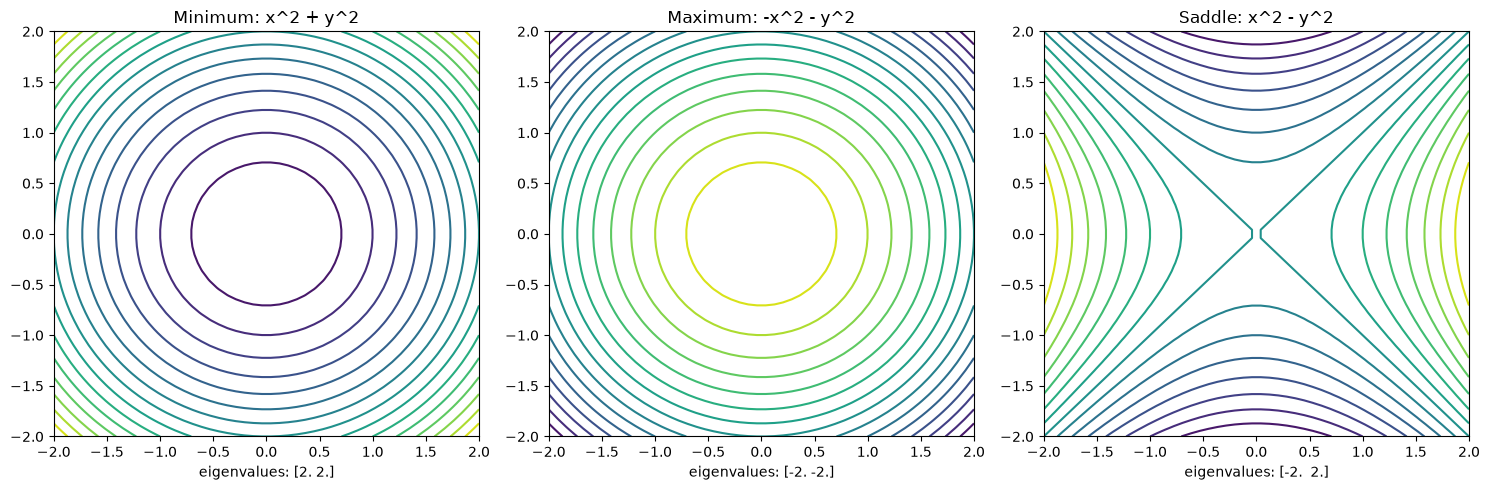

In [9]:
# Three 2D functions showing min, max, saddle
functions = {
    'Minimum: x^2 + y^2':       (lambda x, y: x**2 + y**2, [2, 0, 0, 2]),
    'Maximum: -x^2 - y^2':      (lambda x, y: -x**2 - y**2, [-2, 0, 0, -2]),
    'Saddle: x^2 - y^2':        (lambda x, y: x**2 - y**2, [2, 0, 0, -2]),
}

x = np.linspace(-2, 2, 50)
y = np.linspace(-2, 2, 50)
X, Y = np.meshgrid(x, y)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, (f, H)) in zip(axes, functions.items()):
    Z = f(X, Y)
    ax.contour(X, Y, Z, levels=15, cmap='viridis')
    ax.set_title(title)
    eigs = np.linalg.eigvalsh(np.array(H).reshape(2, 2))
    ax.set_xlabel(f"eigenvalues: {eigs}")
plt.tight_layout()
plt.show()

## Key Takeaways

- **Chain rule** = how derivatives compose; core of backprop
- **Jacobian** = matrix of first derivatives of a vector function ($m \times n$)
- **Hessian** = matrix of second derivatives of a scalar function ($n \times n$, symmetric)
- **Hessian eigenvalues** tell us min / max / saddle
- **Backprop** = chain rule applied repeatedly over layers
- **Newton's method** uses Hessian for faster convergence

## Connection to ML

- Every neural network training step uses chain rule
- Jacobian shape determines gradient flow in networks
- Hessian reveals curvature; Adam approximates it implicitly
- Saddle points (not local minima) are the main obstacle in deep learning